In [1]:
# Standard library imports
import os
import random
import sys

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cProfile
import pstats

# Configure matplotlib
plt.style.use('fig.style')
figsize = (8,4)

# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

# Local imports
from src.get_hg_projection_matrix import get_hg_projection_matrix
from src.matrix_visualizer import visualize_matrix
from src.seq_embedder import SeqEmbedder
from src.get_adjacent_features_upto_order import get_adjacent_features_upto_order

from src import (
    get_additive_model_features, 
    get_pairwise_model_features,
    get_neighbor_model_features,
    get_K_order_model_features,
    get_K_adjacent_model_features,
    get_all_order_model_features
)
from src import get_alphabet

pairwise:
features[:num_to_show]=['****', '***A', '***C', '***G', '***T', '**A*', '**C*', '**G*', '**T*', '*A**']
features[-num_to_show:]=['**G*', '**T*', '*A**', '*C**', '*G**', '*T**', 'A***', 'C***', 'G***', 'T***']



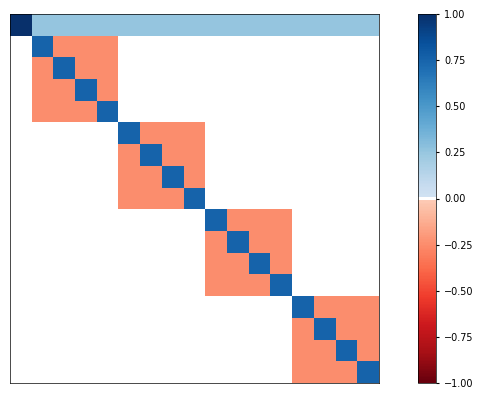

In [2]:
L = 4
alphabet = ['A', 'C', 'G', 'T']  
num_to_show = 10
features = get_additive_model_features(L=L, alphabet=alphabet)
print(f'pairwise:\n{features[:num_to_show]=}\n{features[-num_to_show:]=}\n')

P = get_hg_projection_matrix(features=features, alphabet=alphabet, bg_type='uniform', wildcard_char='*', out_type='df')
visualize_matrix(P.values, show_grid=False, figsize=figsize)


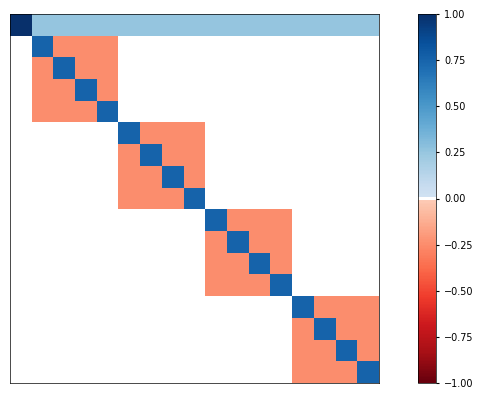

In [4]:
from scipy.sparse import lil_matrix
def get_additive_hg_projection_matrix(L, alphabet):
    alpha = len(alphabet)
    
    # Get matrix size
    N = 1 + alpha*L
    
    # Initialize matrix
    mat = lil_matrix((N, N))
    
    # Set first row
    mat[0,0] = 1.0  
    mat[0,1:] = 1/alpha
    
    # Set block diagonal elements
    shift = 1
    block = np.eye(alpha) - 1/alpha
    for i in range(L):
        start = shift + alpha*i
        stop = start + alpha
        mat[start:stop, start:stop] = block
        
    # Convert to CSR format for efficient operations
    mat = mat.tocsr()
    return mat
    
mat = get_additive_hg_projection_matrix(L=L, alphabet=alphabet)
visualize_matrix(mat.todense(), show_grid=False, figsize=figsize)


In [ ]:
diags = np.ones(N)
diags

In [ ]:
L = 5
K = 3
alphabet = ['A', 'B']  
num_to_show = 10

features = get_additive_model_features(L=L, alphabet=alphabet)
print(f'additive:\n{features[:num_to_show]=}\n{features[-num_to_show:]=}\n')

features = get_pairwise_model_features(L=L, alphabet=alphabet)
print(f'pairwise:\n{features[:num_to_show]=}\n{features[-num_to_show:]=}\n')

features = get_neighbor_model_features(L=L, alphabet=alphabet)
print(f'neighbor:\n{features[:num_to_show]=}\n{features[-num_to_show:]=}\n')

features = get_K_order_model_features(L=L, K=K, alphabet=alphabet)
print(f'K-order, {K=}:\n{features[:num_to_show]=}\n{features[-num_to_show:]=}\n')

features = get_K_adjacent_model_features(L=L, K=K, alphabet=alphabet)
print(f'K-adjacent, {K=}:\n{features[:num_to_show]=}\n{features[-num_to_show:]=}\n')

features = get_all_order_model_features(L=L, alphabet=alphabet)
print(f'all:\n{features[:num_to_show]=}\n{features[-num_to_show:]=}\n')

In [ ]:
L = 40
alphabet = ['A', 'C', 'G', 'T']  
features = get_pairwise_model_features(L=L, alphabet=alphabet)
N = len(features)
theta = pd.Series(index=features, data=np.random.randn(N))
print(f'{L=}\n{N=:,}\n{alphabet=}\n{theta[:5]=}\n{theta[-5:]=}')

# Needed for profiling
wt_seq = ('ACGT'*L)[:L]
bg_df = pd.DataFrame(index=range(L), columns=alphabet, data={'A': .1, 'C': .4, 'G': .4, 'T': .1})


In [ ]:
# Make Olson et al. features
L = 10 #55
alphabet = get_alphabet('protein')
wt_seq = 'QYKLI LNGKT LKGET TTGAV DAATA EKVFK QYAND NGVDG EWTYD DATKT FTVTE'.replace(' ', '')[:L]
assert len(wt_seq) == L, f'{len(wt_seq)=} != {L=}'
features = get_pairwise_model_features(L=L, alphabet=alphabet)
theta = pd.Series(index=features, data=np.random.randn(N))
N = len(features)
print(f'{L=}\n{N=:,}\n{alphabet=}')
print(f'Olson et al. features:\n{features[:num_to_show]=}\n{features[-num_to_show:]=}')
print(f'\n{theta[:5]=}\n{theta[-5:]=}')


In [ ]:
# Default keyword arguments that are common across all background types
default_kwargs = {
    'features': features,
    'alphabet': alphabet, 
    'wildcard_char': '*',
    'out_type': 'sparse'
}

# Variable keyword arguments for different background types
bg_type_kwargs = {
    'wildtype': {'bg_type': 'wildtype', 'wt_seq': wt_seq},
    #'uniform': {'bg_type': 'uniform'},
    #'custom': {'bg_type': 'custom', 'bg_df': bg_df},
}

# Update each params dict with the default kwargs
for bg_type in bg_type_kwargs:
    bg_type_kwargs[bg_type].update(default_kwargs)

# Loop over background types
for bg_type, kwargs in bg_type_kwargs.items():
    print(f"\nProfiling with {bg_type} background:")
    with cProfile.Profile() as profiler:
        P = get_hg_projection_matrix(**kwargs)
        
    stats = pstats.Stats(profiler)
    stats.strip_dirs().sort_stats('cumulative').print_stats(10)


In [ ]:
# Get encoder; use to encode sequences
embedder = SeqEmbedder(features=features)

# Check that gauge matches for every sequence
num_seqs_to_test = 100
for seq_num in range(num_seqs_to_test):
    seq = ''.join(random.choices(alphabet, k=L))

    # Get embedded sequence
    x =embedder.embed(seq)

    # Compute function using the two vectors
    f = theta@x
    f_fixed = (P@theta)@x
    
    # Check that the two functions are close
    assert np.isclose(f, f_fixed), f'{f=}\n{f_fixed=}'
print(f'Tested {num_seqs_to_test} random sequences; all seqs passed.')

# Visualize projection matrix
#visualize_matrix(P.values, show_grid=False, figsize=figsize)

In [ ]:
P.nnz

In [12]:
# I should try to write shortcut code to gauge fix large pairwise models. 